# Rate design — the cost of information, and the budget-optimal declared schedule

**Who this is for.** This notebook is written to be readable without a
technical background. Every term of art gets a short explanation, in
parentheses, at its first use. It reuses finished machinery only: the
required-rate schedules from `step3_analysis` (t09), the published outlays
(t12) and bills (t08), the per-world bills from `bridge_detection` (b07), the
noisy-observer formula from `bridge_detection` stage 3, and the delivery
verdicts from the `itcfbm` model runs (r01/r03). No new model runs.

**The two questions.**

- **Part A — the cost of information.** An observer watches construction
  costs come in, year by year, corrupted by noise. How many units, years, and
  subsidy dollars pass before the observer can pin down the industry's
  **learning rate** (the fractional cost drop per doubling of built
  capacity) — and, more usefully, the **required support scale** (how much
  credit the program actually needs) — to a stated confidence?
- **Part B — the strategic rate.** A decision maker declares a support
  schedule in advance under a firm present-value budget X. Instead of scaling
  one model world's schedule, we search over schedules of **any shape** for
  the one that delivers the largest share of cost worlds while its
  world-invariant outlay stays at or under X. The result is a family of
  **contours**: one near-optimal declared schedule per budget level.

**The gatekeeping contract.** `methods.md` was written before this notebook
was executed. It registers hard arithmetic gates (G0-G4) and, new for this
directory, **kill criteria** (K1-K7): pre-registered rules that exclude an
analysis from the paper if its own results are weak, unstable, or
unquotable. The final cell dispositions every one of them into
`u90_verdict.csv`.

The six mandate schedules, smallest to largest: eia, aj, iaea, mck, cop28,
eo. Run on the **playground-env** kernel. Tables are `u`-numbered, figures
`w`-numbered.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, str(Path.cwd().parent))
import plotstyle as ps

ps.apply()
pd.set_option("display.width", 220)

HERE = Path.cwd()
assert HERE.name == "rate_design", f"run from z-ethan/rate_design/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

MC_EXPORTS = REPO / "z-ethan" / "mc" / "exports"
CHECKS3 = REPO / "z-ethan" / "step3_checks" / "exports"
S3ANALYSIS = REPO / "z-ethan" / "step3_analysis" / "exports"
ITCFBM = REPO / "z-ethan" / "itcfbm_analysis" / "exports"
BRIDGE = REPO / "z-ethan" / "bridge_detection" / "exports"

SEED = 20260901
TOL_SHORT = 0.01          # delivery cushion, statutory rate points (r03-certified)
LEVELS = [(0.15, 0.05), (0.30, 0.10), (0.50, 0.20)]   # (sigma, tau); mid = headline
LV_MID = (0.30, 0.10)
R = 10                    # noise histories per truth world (stage-3 convention)
N_TRUTH = 500             # truth worlds per schedule, drawn uniformly (methods.md)
UNIT_MW = 300
BUDGET_MULTS = [0.75, 1.0, 1.25, 1.5, 2.0]   # reported contour budgets, x p50 bill
ESS_FLOOR = 100.0         # K5
VERDICT = []              # (kind, name, result, detail) rows -> u90

# ---- the MC ensemble --------------------------------------------------------------
Z = np.load(MC_EXPORTS / "mc_perdraw.npz")
META = json.loads(str(Z["meta_json"]))
assert META["n_draws"] == 10000 and META["master_seed"] == 20260715, META
YI = {int(y): i for i, y in enumerate(Z["years"])}

SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]  # ambition order
AB2TOK = {"eia": "eia_aeo_high", "aj": "abou_jaoude", "iaea": "iaea_high",
          "mck": "mckinsey", "cop28": "cop28", "eo": "eo2025"}
TOK2AB = {v: k for k, v in AB2TOK.items()}
NAME2AB = {str(n): TOK2AB[str(t)] for n, t in zip(Z["sched_order"], Z["scen_tokens"])}
WCOLS = [str(c) for c in Z["world_columns"]]
LR_SMR = {ab: Z[f"worlds_{AB2TOK[ab]}"][:, WCOLS.index("lr_smr")] for ab in SCHEDULES}

reg_smr = pd.read_csv(MC_EXPORTS / "smr100" / "selected_draws.csv")
reg_smr["ab"] = reg_smr["schedule"].map(NAME2AB)
assert len(reg_smr) == 18 and reg_smr["ab"].notna().all()
ANCH = {ab: {} for ab in SCHEDULES}
for _, r in reg_smr.iterrows():
    ANCH[r["ab"]][r["percentile"]] = int(r["draw_index"])

# ---- discount rate and price level (must reproduce the study constants) -----------
FIN_DIR = REPO / "inputs" / "financials"
sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
sys_fin = sys_fin.merge(infl, on="t", how="left")
sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                    + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                      * (1 - sys_fin["tax_rate"]) + 1)
sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]
_s = sys_fin.set_index("t")["d_real"].reindex(range(1990, 2051)).ffill()
DR = float(np.mean(_s.loc[np.arange(2010, 2051)].to_numpy(float)))
assert round(DR, 4) == 1.0455, DR
_infl = infl.set_index("t")["inflation_rate"]
D2224 = float(_infl.loc[2023] * _infl.loc[2024])
assert 1.0 < D2224 < 1.2, D2224

# ---- mandate additions and the observation calendar -------------------------------
duals3 = pd.read_csv(CHECKS3 / "duals_by_year.csv")
FLOOR = duals3[duals3["t"] <= 2030].groupby("case")["mandate_MW"].max()
duals3["program_MW"] = (duals3["mandate_MW"]
                        - duals3["case"].map(FLOOR).fillna(0.0)).clip(lower=0.0)
DCASE = {c: g.set_index("t") for c, g in duals3.groupby("case")}

# ---- published tables -------------------------------------------------------------
t08 = pd.read_csv(S3ANALYSIS / "t08_rental_transfer.csv").set_index("case")
t09 = pd.read_csv(S3ANALYSIS / "t09_required_itc.csv")
t09r = t09[t09["status"] == "rate"].set_index(["case", "t"])["i_model_headline"]
t12 = pd.read_csv(S3ANALYSIS / "t12_fiscal_comparison.csv").set_index("case")

def rate_of(case, t):
    v = t09r.get((case, t), 0.0)
    return float(v) if np.isfinite(v) else 0.0

# ---- per-world bills (the Part A spend axis) + gate G0 ----------------------------
BW = np.load(BRIDGE / "b07_bills_perworld.npz")
BILL_YEARS = [int(y) for y in BW["obs_years"]]          # 2031..2050 annual
B2050 = {ab: BW[f"b2050_{ab}"] for ab in SCHEDULES}
BILLS_T = {ab: BW[f"bills_{ab}"] for ab in SCHEDULES}   # (10000, 20) cumulative 2024 $B
g0_fail = []
for ab in SCHEDULES:
    for p in ["p05", "p50", "p95"]:
        pub = float(t08.loc[f"smr100_{ab}_{p}", "PV_rental_transfer_2024B"])
        if abs(B2050[ab][ANCH[ab][p]] - pub) > 0.051:
            g0_fail.append((ab, p))
G0 = not g0_fail
assert G0, g0_fail
P50BILL = {ab: float(t08.loc[f"smr100_{ab}_p50", "PV_rental_transfer_2024B"])
           for ab in SCHEDULES}
VERDICT.append(("gate", "G0", "PASS",
                "b07 per-world bills reproduce published t08 at all 18 anchors (<=0.051 $B)"))
print("G0 PASS; p50 bills (2024 $B):", {k: round(v, 1) for k, v in P50BILL.items()})


G0 PASS; p50 bills (2024 $B): {'eia': 31.1, 'aj': 32.7, 'iaea': 91.8, 'mck': 116.3, 'cop28': 190.8, 'eo': 331.9}


## S1 — every world gets a requirement path and a threshold

Only the 3 anchor worlds per schedule carry model-computed required rates
(t09: the headline rate per build year — the credit sufficient in the
highest-need building region that year). Every other world's rates are
interpolated per build year: the three anchor points (that year's build cost
against that year's required rate) are connected with straight line segments,
and a world's rate is read off at its own build cost, held flat outside the
outer anchors. The stage-2 predict-the-middle test certifies this family to
±20%; kill criterion K3 carries that band through Part B.

From the interpolated rates, with the one-point cushion the model runs
certify (r03):

- **need_w(t)** — the dollars per kilowatt that deliver world w in year t:
  (required rate − 0.01) × the world's own build cost, floored at zero.
- **f\*_w** — the smallest scale on the **reference** (the p50 anchor's
  declared $/kW path) that covers need_w in every build year: the world's
  decision-relevant summary — how much support it actually needs.
- **Outlay pricing** (fixed basis, world-invariant): the present value of an
  offered $/kW schedule is kappa × Σ offer(t) × additions(t) × discount(t),
  with kappa calibrated per schedule to the published t12 outlays (gate G3).

This cell re-asserts the instrument_comparison gates on the replicated
machinery (G1 interpolation identity, G2 feed-back consistency, G3
calibration residual) and re-derives the thresholds; they must match the
stored `s01` export exactly.

In [2]:
ADD, DISC, BUILD_TS = {}, {}, {}
IREF, IW, OCCW, NEED = {}, {}, {}, {}
REFC, FSTAR, COVER, BINDY = {}, {}, {}, {}
KAPPA, KAP_RES, SPREF, IBAR, WPRICE = {}, {}, {}, {}, {}
TOPKNOT_PCT, UPCLAMP = {}, {}
g1_fail = []

for ab in SCHEDULES:
    d0 = DCASE[f"smr100_{ab}_p05"]
    build_ts = [int(t) for t in d0.index if t >= 2026 and d0.loc[t, "program_MW"] > 0]
    prog = np.array([d0.loc[t, "program_MW"] for t in build_ts])
    add = np.diff(prog, prepend=0.0).clip(min=0.0)
    disc = np.array([DR ** -(t - 2026) for t in build_ts])
    keep = add > 0
    BUILD_TS[ab] = [t for t, k in zip(build_ts, keep) if k]
    ADD[ab] = add[keep]
    DISC[ab] = disc[keep]

    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    occ_t = np.stack([occ[:, YI[t]] for t in BUILD_TS[ab]], axis=1)  # 2022 $/kW
    OCCW[ab] = occ_t * D2224                                        # 2024 $/kW
    cases = {p: f"smr100_{ab}_{p}" for p in ["p05", "p50", "p95"]}

    iw = np.empty_like(occ_t)
    topknot = np.empty(len(BUILD_TS[ab]))
    for j, t in enumerate(BUILD_TS[ab]):
        xs = np.array([occ[ANCH[ab][p], YI[t]] for p in ["p05", "p50", "p95"]])
        ys = np.array([rate_of(cases[p], t) for p in ["p05", "p50", "p95"]])
        o = np.argsort(xs)
        xs, ys = xs[o], ys[o]
        assert np.all(np.diff(xs) > 0), (ab, t, xs)
        iw[:, j] = np.interp(occ_t[:, j], xs, ys)
        topknot[j] = xs[-1]
    IW[ab] = iw
    IREF[ab] = np.array([rate_of(cases["p50"], t) for t in BUILD_TS[ab]])
    TOPKNOT_PCT[ab] = np.array([float((occ_t[:, j] <= topknot[j]).mean())
                                for j in range(len(BUILD_TS[ab]))])
    UPCLAMP[ab] = np.any(occ_t > topknot[None, :], axis=1)

    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        tru = np.array([rate_of(cases[p], t) for t in BUILD_TS[ab]])
        if np.max(np.abs(iw[w_] - tru)) > 1e-9:
            g1_fail.append((ab, p, "anchor rate identity"))

    # the dollar requirement and the threshold on the reference $/kW path
    need_rate = np.maximum(iw - TOL_SHORT, 0.0)
    NEED[ab] = need_rate * OCCW[ab]                       # 2024 $/kW per year
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    REFC[ab] = IREF[ab] * occ_ref                          # reference $/kW path
    with np.errstate(divide="ignore", invalid="ignore"):
        f_ratio = np.where(NEED[ab] > 0,
                           NEED[ab] / np.where(REFC[ab] > 0, REFC[ab], np.nan)[None, :],
                           0.0)
    uncov = np.any((NEED[ab] > 0) & (REFC[ab][None, :] <= 0), axis=1)
    COVER[ab] = ~uncov
    FSTAR[ab] = np.where(uncov, np.inf,
                         np.nanmax(np.where(NEED[ab] > 0, f_ratio, 0.0),
                                   axis=1, initial=0.0))
    BINDY[ab] = np.array(BUILD_TS[ab])[
        np.nanargmax(np.where(NEED[ab] > 0, f_ratio, -1.0), axis=1)]

    # p50 calibration-point identity (the cushion identity)
    w50 = ANCH[ab]["p50"]
    exp50 = float(np.max(np.maximum(IREF[ab] - TOL_SHORT, 0.0)
                         / np.where(IREF[ab] > 0, IREF[ab], np.inf)))
    if abs(FSTAR[ab][w50] - exp50) > 1e-9:
        g1_fail.append((ab, "p50", "calibration-point identity"))

    # outlay calibration to published t12 (gate G3) + the pricing weights
    raw_own = {}
    for p in ["p05", "p50", "p95"]:
        w_ = ANCH[ab][p]
        i_own = np.array([rate_of(cases[p], t) for t in BUILD_TS[ab]])
        raw_own[p] = float(np.sum(i_own * OCCW[ab][w_] * ADD[ab] * DISC[ab]) * 1000 / 1e9)
    pub = {p: float(t12.loc[cases[p], "PV_ITC_outlay_2024B"]) for p in ["p05", "p50", "p95"]}
    KAPPA[ab] = float(np.mean([pub[p] / raw_own[p] for p in ["p05", "p50", "p95"]]))
    KAP_RES[ab] = max(abs(KAPPA[ab] * raw_own[p] / pub[p] - 1) for p in ["p05", "p50", "p95"])
    WPRICE[ab] = KAPPA[ab] * ADD[ab] * DISC[ab] * 1000 / 1e9   # $B per ($/kW offered)
    SPREF[ab] = float(REFC[ab] @ WPRICE[ab])
    wgt_val = occ_ref * ADD[ab] * DISC[ab]
    IBAR[ab] = float(np.sum(IREF[ab] * wgt_val) / wgt_val.sum())

G1 = not g1_fail
assert G1, g1_fail
VERDICT.append(("gate", "G1", "PASS",
                "interpolation exact at all 18 anchors; p50 f* at the calibration point"))
G3 = all(KAP_RES[ab] <= 0.07 for ab in SCHEDULES)
assert G3, {ab: round(KAP_RES[ab], 3) for ab in SCHEDULES}
VERDICT.append(("gate", "G3", "PASS",
                "outlay calibration residual <= 7% at all 18 anchors"))
assert all(COVER[ab].all() for ab in SCHEDULES), "uncoverable worlds appeared"

# G2: the reference equals what the feed-back runs fed; r03 bracket unchanged
r01 = pd.read_csv(ITCFBM / "r01_rate_ladder.csv")
r03 = pd.read_csv(ITCFBM / "r03_minimality_verdicts.csv")
heads = r01.drop_duplicates(["world", "t"]).set_index(["world", "t"])["i_head"]
g2_fail = []
for ab in ["aj", "mck", "eo"]:
    ts = sorted(set(heads.loc[ab].index) & set(BUILD_TS[ab]))
    diff = max(abs(float(heads.loc[(ab, t)]) - rate_of(f"smr100_{ab}_p50", t)) for t in ts)
    if diff > 1e-6:
        g2_fail.append((ab, round(diff, 6)))
if not (set(r03["deepest_delivering_rung"]) == {"m01"}
        and set(r03["shallowest_failing_rung"]) == {"m05"}):
    g2_fail.append(("r03", "bracket changed"))
G2 = not g2_fail
assert G2, g2_fail
VERDICT.append(("gate", "G2", "PASS",
                "reference = fed r01 headline (<=1e-6, aj/mck/eo); r03 bracket (head-5, head-1]"))

# must match the stored instrument_comparison thresholds exactly
s01_old = pd.read_csv(REPO / "z-ethan" / "instrument_comparison" / "exports"
                      / "s01_per_world_thresholds.csv")
for ab in SCHEDULES:
    ref = s01_old[s01_old["schedule"] == ab].sort_values("world")["fstar"].to_numpy()
    assert np.allclose(np.round(FSTAR[ab], 4), ref, atol=5e-4), ab
print("G1/G2/G3 PASS; f* matches the stored s01 export in all six schedules")

u01 = pd.concat([pd.DataFrame({
    "schedule": ab, "world": np.arange(10000),
    "fstar": np.round(FSTAR[ab], 4), "binding_year": BINDY[ab],
    "upper_clamped": UPCLAMP[ab], "lr_smr": np.round(LR_SMR[ab], 4),
    "bill_2050_2024B": np.round(B2050[ab], 2),
}) for ab in SCHEDULES], ignore_index=True)
u01.to_csv(EXPORTS / "u01_per_world_requirements.csv", index=False)
print(f"u01: {len(u01)} rows")


G1/G2/G3 PASS; f* matches the stored s01 export in all six schedules


u01: 60000 rows


## S2 — Part A: what does it cost to know the learning curve?

The observer is the stage-3 observer, formula unchanged: each observation
year it sees the geometric mean of that year's unit costs, corrupted by a
shared industry shock (tau, common to every unit that year) and per-project
scatter (sigma, averaging down with the number of units n as sigma/sqrt(n)).
Every one of the 10,000 candidate worlds carries a running weight — how
probable the observations so far would be if that world were true — and
every estimate below is a weighted quantile over the prior.

Per schedule, noise level, truth world (500 drawn uniformly, seeded), and
noise history (R = 10), after each observation year we record the CI widths
for four quantities:

- the **learning rate** `lr_smr` (5th–95th; co-headline),
- the **required-rate scale f\*** (5th–95th; co-headline — the
  decision-relevant estimate, linking Part A to Part B),
- the **2050 build cost** and the **2050 total program cost** (10th–90th,
  relative to the weighted median; companion/debug curves),
- and the **effective sample size** (ESS — how many worlds effectively
  carry the posterior; the degeneracy diagnostic).

The axes translate observation years into cumulative units (the mandate
build) and cumulative spend (the truth world's own bill, b07). The
**perfect-observation bound** (no noise) is computed by elimination and is
expected to identify the world almost immediately — the price of
information is a property of observation noise.

In [3]:
# observation calendar (stage-3 construction, re-derived)
OBSCAL, N_UNITS, CUMU, LOGOCC = {}, {}, {}, {}
for ab in SCHEDULES:
    d = duals3[duals3["case"] == f"smr100_{ab}_p05"].set_index("t").sort_index()
    ts = [int(t) for t in d.index if t >= 2031]
    prev, years, units = 0.0, [], []
    for t in ts:
        add = float(d.loc[t, "program_MW"]) - prev
        prev = float(d.loc[t, "program_MW"])
        if add > 0:
            years.append(t)
            units.append(max(1, int(round(add / UNIT_MW))))
    OBSCAL[ab] = np.array(years)
    N_UNITS[ab] = np.array(units, dtype=float)
    CUMU[ab] = np.cumsum(N_UNITS[ab])
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    LOGOCC[ab] = np.log(occ[:, [YI[t] for t in years]])

rng = np.random.default_rng(SEED)
TRUTH = {ab: np.sort(rng.choice(10000, size=N_TRUTH, replace=False))
         for ab in SCHEDULES}

QVARS = {   # name -> (values, lo_q, hi_q, relative?)
    "lr":   (None, 0.05, 0.95, False),
    "fstar": (None, 0.05, 0.95, False),
    "occ50": (None, 0.10, 0.90, True),
    "bill": (None, 0.10, 0.90, True),
}

def sweep_ci(ab, lv, worlds, rng_local):
    """Weighted-CI sweep (stage-3 likelihood formula). Returns per-variable
    width arrays (nW, K, R), the ESS array, and per-truth spend paths."""
    sig, tau = lv
    L0 = LOGOCC[ab]
    n = N_UNITS[ab]
    var = tau ** 2 + sig ** 2 / n
    K = L0.shape[1]
    vals = {
        "lr": LR_SMR[ab], "fstar": FSTAR[ab],
        "occ50": Z[f"occ_{AB2TOK[ab]}_smr"][:, YI[2050]] * D2224,
        "bill": B2050[ab],
    }
    orders = {k: np.argsort(v) for k, v in vals.items()}
    vsort = {k: v[orders[k]] for k, v in vals.items()}
    nW = len(worlds)
    widths = {k: np.empty((nW, K, R), dtype=np.float32) for k in QVARS}
    ess = np.empty((nW, K, R), dtype=np.float32)
    for i, w in enumerate(worlds):
        eta = rng_local.normal(0, tau, size=(K, R))
        zbar = rng_local.normal(0, 1, size=(K, R)) * (sig / np.sqrt(n))[:, None]
        Y = L0[w][:, None] + eta + zbar
        D = (L0[:, :, None] - Y[None, :, :]) ** 2 / (2 * var)[None, :, None]
        cl = -np.cumsum(D, axis=1)
        cl -= cl.max(axis=0, keepdims=True)
        W = np.exp(cl)                       # (10000, K, R)
        tw = W.sum(axis=0)
        ess[i] = (tw ** 2 / (W ** 2).sum(axis=0)).astype(np.float32)
        for k, (_, lo, hi, rel) in QVARS.items():
            Ws = W[orders[k]]
            cw = np.cumsum(Ws, axis=0) / tw[None, :, :]
            i_lo = (cw < lo).sum(axis=0).clip(0, 9999)
            i_hi = (cw < hi).sum(axis=0).clip(0, 9999)
            v_lo = vsort[k][i_lo]
            v_hi = vsort[k][i_hi]
            if rel:
                i_md = (cw < 0.5).sum(axis=0).clip(0, 9999)
                v_md = vsort[k][i_md]
                widths[k][i] = ((v_hi - v_lo) / np.maximum(v_md, 1e-9)).astype(np.float32)
            else:
                widths[k][i] = (v_hi - v_lo).astype(np.float32)
    return widths, ess

RESA = {}   # (ab, lv) -> dict(widths=..., ess=...)
for ab in SCHEDULES:
    for lv in LEVELS:
        w_, e_ = sweep_ci(ab, lv, TRUTH[ab], rng)
        RESA[(ab, lv)] = dict(widths=w_, ess=e_)
    print(ab, "done")


eia done


aj done


iaea done


mck done


cop28 done


eo done


### G4a — the weight formula against a brute-force reimplementation

The vectorized computation above is re-done for one seeded spot case (mck,
mid noise, one truth world, one history) with a plain per-world loop that
multiplies Gaussian likelihoods year by year. The two weight vectors must
agree to 1e-10 — this guards broadcasting and cumulative-sum bugs, the
classic failure mode of vectorized likelihood code.

In [4]:
ab0, (sig0, tau0) = "mck", LV_MID
rng_g4 = np.random.default_rng(SEED + 1)
L0 = LOGOCC[ab0]
n0 = N_UNITS[ab0]
var0 = tau0 ** 2 + sig0 ** 2 / n0
K0 = L0.shape[1]
w0 = int(TRUTH[ab0][0])
eta0 = rng_g4.normal(0, tau0, size=K0)
zb0 = rng_g4.normal(0, 1, size=K0) * (sig0 / np.sqrt(n0))
Y0 = L0[w0] + eta0 + zb0

# vectorized (the sweep formula, K cumulative)
D0 = (L0 - Y0[None, :]) ** 2 / (2 * var0)[None, :]
clv = -np.cumsum(D0, axis=1)
clv -= clv.max(axis=0, keepdims=True)
Wv = np.exp(clv[:, -1])
Wv /= Wv.sum()

# brute force: plain loop, explicit Gaussian product per world
Wb = np.zeros(10000)
for m in range(10000):
    p = 1.0
    for j in range(K0):
        p *= np.exp(-(L0[m, j] - Y0[j]) ** 2 / (2 * var0[j]))
    Wb[m] = p
Wb /= Wb.sum()
g4a_err = float(np.max(np.abs(Wv - Wb)))
G4a = g4a_err < 1e-10
assert G4a, g4a_err
VERDICT.append(("gate", "G4a", "PASS",
                f"vectorized weights = brute-force Gaussian product (max diff {g4a_err:.1e})"))
print(f"G4a PASS (max weight diff {g4a_err:.2e})")


G4a PASS (max weight diff 4.34e-18)


### The CI curves, the price of information, and the degeneracy table

Aggregation: per schedule × noise level × observation year, the **median CI
width over truth worlds × histories**, with quartiles; the spend axis is the
median cumulative bill over truth worlds at that year. The **price of
information** is the first observation year at which the median f\* CI
width fits inside the registered targets — the r03 marginal band (5 rate
points in scale units) and the one-point cushion (1 point) — with the
replication spread (K6) and the ESS floor (K5) checked at the crossing.

The perfect-observation bound: with no noise, how many candidate worlds
match the observed cost path exactly after one observation?

In [5]:
TGT5 = {ab: 0.05 / IBAR[ab] for ab in SCHEDULES}   # r03 marginal band, scale units
TGT1 = {ab: 0.01 / IBAR[ab] for ab in SCHEDULES}   # one-point cushion, scale units

rows10, rows11, rows12 = [], [], []
k6_detail, k7_detail = [], []
for ab in SCHEDULES:
    tr = TRUTH[ab]
    spend = BILLS_T[ab][tr][:, [BILL_YEARS.index(t) for t in OBSCAL[ab]]]
    spend_med = np.median(spend, axis=0)
    for lv in LEVELS:
        wd = RESA[(ab, lv)]["widths"]
        es = RESA[(ab, lv)]["ess"]
        K = wd["lr"].shape[1]
        # prior widths (k = 0)
        prior = {}
        for k, (_, lo, hi, rel) in QVARS.items():
            v = {"lr": LR_SMR[ab], "fstar": FSTAR[ab],
                 "occ50": Z[f"occ_{AB2TOK[ab]}_smr"][:, YI[2050]] * D2224,
                 "bill": B2050[ab]}[k]
            qlo, qmd, qhi = np.quantile(v, [lo, 0.5, hi])
            prior[k] = (qhi - qlo) / qmd if rel else qhi - qlo
        rows10.append(dict(schedule=ab, sigma=lv[0], tau=lv[1], year=0, k=0,
                           units=0, spend_med=0.0, ess_med=10000.0, ess_q10=10000.0,
                           **{f"{k}_w_med": round(float(prior[k]), 4) for k in QVARS},
                           **{f"{k}_w_q25": np.nan for k in QVARS},
                           **{f"{k}_w_q75": np.nan for k in QVARS}))
        for j in range(K):
            row = dict(schedule=ab, sigma=lv[0], tau=lv[1],
                       year=int(OBSCAL[ab][j]), k=j + 1,
                       units=int(CUMU[ab][j]), spend_med=round(float(spend_med[j]), 2),
                       ess_med=round(float(np.median(es[:, j, :])), 1),
                       ess_q10=round(float(np.quantile(es[:, j, :], 0.10)), 1))
            for k in QVARS:
                row[f"{k}_w_med"] = round(float(np.median(wd[k][:, j, :])), 4)
                row[f"{k}_w_q25"] = round(float(np.quantile(wd[k][:, j, :], 0.25)), 4)
                row[f"{k}_w_q75"] = round(float(np.quantile(wd[k][:, j, :], 0.75)), 4)
            rows10.append(row)
            rows12.append(dict(schedule=ab, sigma=lv[0], tau=lv[1],
                               year=int(OBSCAL[ab][j]),
                               ess_med=row["ess_med"], ess_q10=row["ess_q10"]))
        # price of information: median f* width crossing, per target
        med_traj = np.array([np.median(wd["fstar"][:, j, :]) for j in range(K)])
        for tgt_name, tgt in [("band5", TGT5[ab]), ("cushion1", TGT1[ab])]:
            hit = np.flatnonzero(med_traj <= tgt)
            if len(hit):
                j0 = int(hit[0])
                ess_at = float(np.median(es[:, j0, :]))
                # replication spread: per-history crossing spend (K6)
                cross = []
                for r_ in range(R):
                    tr_med = np.array([np.median(wd["fstar"][:, j, r_]) for j in range(K)])
                    h_ = np.flatnonzero(tr_med <= tgt)
                    cross.append(spend_med[int(h_[0])] if len(h_) else np.nan)
                cross = np.array(cross, float)
                iqr = (np.nanquantile(cross, 0.75) - np.nanquantile(cross, 0.25)
                       if np.isfinite(cross).sum() >= 3 else np.nan)
                med_cross = float(np.nanmedian(cross))
                rows11.append(dict(schedule=ab, sigma=lv[0], tau=lv[1], target=tgt_name,
                                   tgt_scale=round(tgt, 4), year=int(OBSCAL[ab][j0]),
                                   units=int(CUMU[ab][j0]),
                                   spend_med_2024B=round(float(spend_med[j0]), 2),
                                   spend_over_p50bill=round(float(spend_med[j0]) / P50BILL[ab], 3),
                                   rep_iqr_2024B=round(float(iqr), 2) if np.isfinite(iqr) else np.nan,
                                   rep_iqr_over_med=round(float(iqr / med_cross), 3)
                                   if np.isfinite(iqr) and med_cross > 0 else np.nan,
                                   ess_med_at_cross=round(ess_at, 1),
                                   quotable=bool(ess_at >= ESS_FLOOR)))
                if lv == LV_MID and tgt_name == "band5":
                    k6_detail.append((ab, float(iqr / med_cross)
                                      if np.isfinite(iqr) and med_cross > 0 else np.nan))
            else:
                rows11.append(dict(schedule=ab, sigma=lv[0], tau=lv[1], target=tgt_name,
                                   tgt_scale=round(tgt, 4), year=-1, units=-1,
                                   spend_med_2024B=np.nan, spend_over_p50bill=np.nan,
                                   rep_iqr_2024B=np.nan, rep_iqr_over_med=np.nan,
                                   ess_med_at_cross=np.nan, quotable=False))
                if lv == LV_MID and tgt_name == "band5":
                    k6_detail.append((ab, np.nan))
        # K7 monotonicity of the mid-noise median trajectory
        if lv == LV_MID:
            up = np.diff(med_traj) / np.maximum(med_traj[:-1], 1e-9)
            k7_detail.append((ab, float(up.max()) if len(up) else 0.0))

u10 = pd.DataFrame(rows10)
u10.to_csv(EXPORTS / "u10_ci_curves.csv", index=False)
u11 = pd.DataFrame(rows11)
u11.to_csv(EXPORTS / "u11_price_of_information.csv", index=False)
u12 = pd.DataFrame(rows12)
u12.to_csv(EXPORTS / "u12_ess.csv", index=False)

# perfect-observation bound (elimination, first 100 truth worlds per schedule)
rows13 = []
for ab in SCHEDULES:
    L0 = LOGOCC[ab]
    cnt1 = [int((np.abs(L0[:, 0] - L0[w, 0]) < 1e-12).sum()) for w in TRUTH[ab][:100]]
    rows13.append(dict(schedule=ab, worlds_consistent_after_1_obs_med=int(np.median(cnt1)),
                       worlds_consistent_after_1_obs_max=int(np.max(cnt1))))
u13 = pd.DataFrame(rows13)
u13.to_csv(EXPORTS / "u13_perfect_obs_bound.csv", index=False)
print(u13.to_string(index=False))
print()
print(u11[u11["sigma"] == LV_MID[0]].to_string(index=False))


schedule  worlds_consistent_after_1_obs_med  worlds_consistent_after_1_obs_max
     eia                                  1                                  1
      aj                                  1                                  1
    iaea                                  1                                  1
     mck                                  1                                  1
   cop28                                  1                                  1
      eo                                  1                                  1

schedule  sigma  tau   target  tgt_scale  year  units  spend_med_2024B  spend_over_p50bill  rep_iqr_2024B  rep_iqr_over_med  ess_med_at_cross  quotable
     eia    0.3  0.1    band5     0.0756    -1     -1              NaN                 NaN            NaN               NaN               NaN     False
     eia    0.3  0.1 cushion1     0.0151    -1     -1              NaN                 NaN            NaN               NaN               NaN 

## S3 — Part B: the budget-optimal declared schedule (contours)

An offered $/kW schedule delivers world w exactly when it covers need_w(t)
in every build year — the same criterion the r03 model runs certified at the
one-point cushion. The cheapest schedule delivering a chosen set of worlds is
the set's **pointwise-maximum envelope**, and its PV outlay is linear in the
schedule. So the design problem — the most worlds within budget X — is a set
choice, solved three ways:

1. **Greedy** (the candidate optimum): grow the covered set one world at a
   time, always adding the world with the smallest incremental envelope
   cost; worlds that fall under the growing envelope join free. The greedy
   path traces capture vs budget in one pass. (Greedy is a heuristic for an
   NP-hard set problem; its capture is a lower bound.)
2. **Quantile family** (the simple baseline): the envelope of the k cheapest
   worlds by f\* ordering, for every k.
3. **Scaled-reference family** (the old menu object): s × the p50 anchor's
   declared path.

Kill criteria: K1 split-half holdout (overfitting), K2 simplicity (greedy
must beat the quantile family by ≥ 1 capture point somewhere or it is
dropped), K3 the ±20% certificate band (the greedy-vs-scaled gain must keep
its sign), K4 the clamp ceiling (a contour whose covered set includes > 5%
upper-clamped worlds is not reported).

In [6]:
def greedy_path(need, wprice, stop_cost):
    """Greedy max-coverage under envelope cost. Returns (costs, counts,
    order, envelopes-at-snapshot dict) where costs/counts trace the path."""
    nw, T = need.shape
    E = np.zeros(T)
    covered = np.all(need <= 1e-12, axis=1)
    costs, counts = [0.0], [int(covered.sum())]
    snaps = []
    cost = 0.0
    while not covered.all():
        deficit = np.clip(need - E[None, :], 0.0, None)
        inc = deficit @ wprice
        inc[covered] = np.inf
        w = int(np.argmin(inc))
        if not np.isfinite(inc[w]):
            break
        cost += float(inc[w])
        E = np.maximum(E, need[w])
        covered |= np.all(need <= E[None, :] + 1e-12, axis=1)
        costs.append(cost)
        counts.append(int(covered.sum()))
        snaps.append((cost, E.copy()))
        if cost > stop_cost:
            break
    return np.array(costs), np.array(counts), snaps

def capture_at(costs, counts, X, denom):
    j = np.searchsorted(costs, X, side="right") - 1
    return counts[max(j, 0)] / denom

def env_at(snaps, X):
    E = None
    for c, e in snaps:
        if c <= X:
            E = e
        else:
            break
    return E

def quantile_path(need, wprice, fstar_order):
    E = np.zeros(need.shape[1])
    costs = np.empty(len(fstar_order))
    for k, w in enumerate(fstar_order):
        E = np.maximum(E, need[w])
        costs[k] = E @ wprice
    return costs   # cost of covering the k+1 cheapest worlds

CONTOUR, CAPTURE = {}, []
u02_rows = []
for ab in SCHEDULES:
    need = NEED[ab]
    wp = WPRICE[ab]
    Xs = np.array(BUDGET_MULTS) * P50BILL[ab]
    stop = 1.1 * Xs.max()

    g_costs, g_counts, g_snaps = greedy_path(need, wp, stop)
    fo = np.argsort(FSTAR[ab], kind="stable")
    q_costs = quantile_path(need, wp, fo)

    # split-half holdout (K1)
    rngH = np.random.default_rng(SEED + 7)
    perm = rngH.permutation(10000)
    A, B = perm[:5000], perm[5000:]
    gA_costs, gA_counts, gA_snaps = greedy_path(need[A], wp, stop)
    foA = np.argsort(FSTAR[ab][A], kind="stable")
    qA_costs = quantile_path(need[A], wp, foA)

    # +/-20% requirement band (K3): rescale the rates, re-derive need and f*
    band = {}
    for tag, mult in [("lo", 0.8), ("hi", 1.2)]:
        need_b = np.maximum(IW[ab] * mult - TOL_SHORT, 0.0) * OCCW[ab]
        with np.errstate(divide="ignore", invalid="ignore"):
            fr = np.where(need_b > 0,
                          need_b / np.where(REFC[ab] > 0, REFC[ab], np.nan)[None, :], 0.0)
        fs_b = np.nanmax(np.where(need_b > 0, fr, 0.0), axis=1, initial=0.0)
        gb_costs, gb_counts, _ = greedy_path(need_b, wp, stop)
        band[tag] = dict(need=need_b, fstar=fs_b, g=(gb_costs, gb_counts))

    for mult, X in zip(BUDGET_MULTS, Xs):
        cap_g = capture_at(g_costs, g_counts, X, 10000)
        kq = np.searchsorted(q_costs, X, side="right")
        cap_q = kq / 10000
        s_aff = X / SPREF[ab]
        cap_s = float((FSTAR[ab] <= s_aff).mean())
        E = env_at(g_snaps, X)
        capA = capture_at(gA_costs, gA_counts, X, 5000)
        EA = env_at(gA_snaps, X)
        capB = (float(np.all(need[B] <= EA[None, :] + 1e-12, axis=1).mean())
                if EA is not None else 0.0)
        kqA = np.searchsorted(qA_costs, X, side="right")
        capqA = kqA / 5000
        EqA = np.zeros(need.shape[1])
        for w in foA[:kqA]:
            EqA = np.maximum(EqA, need[A][w])
        capqB = float(np.all(need[B] <= EqA[None, :] + 1e-12, axis=1).mean())
        # band captures
        cap_g_lo = capture_at(*band["lo"]["g"], X, 10000)
        cap_g_hi = capture_at(*band["hi"]["g"], X, 10000)
        cap_s_lo = float((band["lo"]["fstar"] <= s_aff).mean())
        cap_s_hi = float((band["hi"]["fstar"] <= s_aff).mean())
        # clamp contamination + shape distance
        if E is not None:
            cov_mask = np.all(need <= E[None, :] + 1e-12, axis=1)
            contam = (float(UPCLAMP[ab][cov_mask].mean()) if cov_mask.any() else 0.0)
            occ_ref = OCCW[ab][ANCH[ab]["p50"]]
            shape_dist = float(np.max(np.abs(E - s_aff * REFC[ab]) / occ_ref))
            for j, t in enumerate(BUILD_TS[ab]):
                u02_rows.append(dict(schedule=ab, mult=mult, year=t,
                                     envelope_kW=round(float(E[j]), 1),
                                     rate_equiv=round(float(E[j] / occ_ref[j]), 4),
                                     ref_rate=round(float(IREF[ab][j]), 4)))
        else:
            contam, shape_dist = np.nan, np.nan
        CAPTURE.append(dict(schedule=ab, mult=mult, X_2024B=round(float(X), 1),
                            cap_greedy=round(cap_g, 4), cap_quantile=round(cap_q, 4),
                            cap_scaled=round(cap_s, 4),
                            gain_vs_scaled=round(cap_g - cap_s, 4),
                            gain_vs_quantile=round(cap_g - cap_q, 4),
                            cap_insample_A=round(capA, 4), cap_holdout_B=round(capB, 4),
                            holdout_drop=round(capA - capB, 4),
                            capq_inA=round(capqA, 4), capq_outB=round(capqB, 4),
                            holdout_drop_q=round(capqA - capqB, 4),
                            cap_greedy_lo=round(cap_g_lo, 4), cap_greedy_hi=round(cap_g_hi, 4),
                            cap_scaled_lo=round(cap_s_lo, 4), cap_scaled_hi=round(cap_s_hi, 4),
                            gain_sign_lo=int(np.sign(round(cap_g_lo - cap_s_lo, 4))),
                            gain_sign_hi=int(np.sign(round(cap_g_hi - cap_s_hi, 4))),
                            clamp_contam=round(contam, 4) if np.isfinite(contam) else np.nan,
                            shape_dist_ratepts=round(shape_dist, 4)
                            if np.isfinite(shape_dist) else np.nan))
    CONTOUR[ab] = dict(g=(g_costs, g_counts, g_snaps), q=q_costs, fo=fo)
    print(ab, "contours done")

u03 = pd.DataFrame(CAPTURE)
u03.to_csv(EXPORTS / "u03_capture_table.csv", index=False)
u02 = pd.DataFrame(u02_rows)
u02.to_csv(EXPORTS / "u02_contour_schedules.csv", index=False)
print()
print(u03[["schedule", "mult", "cap_greedy", "cap_quantile", "cap_scaled",
           "gain_vs_scaled", "holdout_drop", "clamp_contam"]].to_string(index=False))


eia contours done


aj contours done


iaea contours done


mck contours done


cop28 contours done


eo contours done

schedule  mult  cap_greedy  cap_quantile  cap_scaled  gain_vs_scaled  holdout_drop  clamp_contam
     eia  0.75      0.0707        0.0592      0.0205          0.0502        0.0036        0.0000
     eia  1.00      0.1569        0.1367      0.1130          0.0439        0.0042        0.0000
     eia  1.25      0.2564        0.2372      0.2312          0.0252        0.0028        0.0000
     eia  1.50      0.3505        0.3471      0.3455          0.0050       -0.0026        0.0000
     eia  2.00      0.5552        0.5531      0.5528          0.0024        0.0076        0.0000
      aj  0.75      0.0270        0.0000      0.0000          0.0270       -0.0004        0.0000
      aj  1.00      0.0824        0.0000      0.0000          0.0824        0.0062        0.0000
      aj  1.25      0.1454        0.0011      0.0000          0.1454        0.0086        0.0000
      aj  1.50      0.2181        0.0066      0.0000          0.2181        0.0056        0.0000
      aj  2.

## S4 — diagnostics: knot drift, clamp shares, binding years

Three structural tables the 2026-09-01 pre-build audit motivated (they are
what an antagonist checks first):

- the **anchor knot drift**: where each anchor draw's cost sits, per year, in
  the 10,000-draw cost distribution — the p50 anchors drift between roughly
  the 20th and 83rd percentiles, which is why the scaled-reference family
  partly prices shape misfit;
- the **clamp shares**: the fraction of worlds outside the interpolation
  knots per year (above the top knot the flat clamp understates the
  requirement — the anti-conservative direction that K4 caps);
- the **binding years**: which build year sets each world's threshold.

In [7]:
d_rows = []
for ab in SCHEDULES:
    occ = Z[f"occ_{AB2TOK[ab]}_smr"]
    for j, t in enumerate(BUILD_TS[ab]):
        col = occ[:, YI[t]]
        for p in ["p05", "p50", "p95"]:
            d_rows.append(dict(metric="knot_pctl", schedule=ab, year=t, key=p,
                               value=round(float((col < occ[ANCH[ab][p], YI[t]]).mean()) * 100, 1)))
        d_rows.append(dict(metric="clamp_above_pct", schedule=ab, year=t, key="",
                           value=round((1 - TOPKNOT_PCT[ab][j]) * 100, 1)))
    bc = pd.Series(BINDY[ab]).value_counts(normalize=True).sort_index() * 100
    for t, v in bc.items():
        d_rows.append(dict(metric="binding_year_pct", schedule=ab, year=int(t), key="",
                           value=round(float(v), 1)))
u20 = pd.DataFrame(d_rows)
u20.to_csv(EXPORTS / "u20_diagnostics.csv", index=False)
piv = u20[u20["metric"] == "binding_year_pct"].pivot_table(
    index="year", columns="schedule", values="value")
print("binding-year % of worlds:")
print(piv.fillna(0.0).round(1).to_string())


binding-year % of worlds:
schedule    aj  cop28   eia    eo  iaea   mck
year                                         
2031      43.2   32.7   0.0  72.8  15.9  44.2
2032      50.0    1.1   0.0   8.4   0.5   4.1
2033       0.1    2.3   0.0   0.3   6.8   2.5
2034       0.1    0.3   0.0   0.1   0.1   0.5
2035       0.1    0.4   0.0   0.7   2.0   0.9
2038       0.3    2.3  55.1   2.4   0.4   1.1
2041       0.4    0.2   5.9  13.2   0.8   0.1
2044       0.0    0.2   0.0   0.1   0.5   0.1
2047       4.1   32.2  36.1   0.0  14.5   8.7
2050       1.7   28.1   3.0   2.0  58.5  37.8


### G4b (soft) — the recomputed bill CI against the published b16 widths

The stage-3 notebook published the relative 10th–90th band width of the
running 2050-bill estimate (b16). The same quantity recomputed here — from a
different, uniformly drawn truth sample — should land within a factor of two
at the shared snapshot years. Reported, not asserted: the samples differ by
design (b16 stratified half expensive worlds).

In [8]:
b16 = pd.read_csv(BRIDGE / "b16_running_estimate_noisy.csv")
rows_g4b = []
for ab in SCHEDULES:
    for lv in LEVELS:
        wd = RESA[(ab, lv)]["widths"]["bill"]
        for T in [2035, 2040, 2045, 2050]:
            js = np.flatnonzero(OBSCAL[ab] <= T)
            if not len(js):
                continue
            mine = float(np.median(wd[:, js[-1], :]))
            pub = b16[(b16["schedule"] == ab) & (b16["sigma"] == lv[0])
                      & (b16["tau"] == lv[1]) & (b16["year"] == T)]
            if len(pub):
                pv = float(pub["median_rel_band_width"].iloc[0])
                rows_g4b.append(dict(schedule=ab, sigma=lv[0], tau=lv[1], year=T,
                                     mine=round(mine, 3), b16=round(pv, 3),
                                     ratio=round(mine / pv, 2) if pv > 0 else np.nan))
g4b = pd.DataFrame(rows_g4b)
in2x = float(((g4b["ratio"] >= 0.5) & (g4b["ratio"] <= 2.0)).mean())
VERDICT.append(("gate", "G4b", "REPORTED",
                f"{in2x:.0%} of {len(g4b)} shared rows within a factor of 2 of b16 "
                "(different truth samples by design)"))
print(f"G4b: {in2x:.0%} of {len(g4b)} rows within 2x of b16")
print(g4b[g4b["year"] == 2050].to_string(index=False))


G4b: 100% of 69 rows within 2x of b16
schedule  sigma  tau  year  mine   b16  ratio
     eia   0.15 0.05  2050 0.183 0.204   0.89
     eia   0.30 0.10  2050 0.359 0.406   0.88
     eia   0.50 0.20  2050 0.648 0.728   0.89
      aj   0.15 0.05  2050 0.130 0.133   0.98
      aj   0.30 0.10  2050 0.258 0.262   0.98
      aj   0.50 0.20  2050 0.472 0.476   0.99
    iaea   0.15 0.05  2050 0.080 0.082   0.97
    iaea   0.30 0.10  2050 0.158 0.163   0.97
    iaea   0.50 0.20  2050 0.302 0.308   0.98
     mck   0.15 0.05  2050 0.088 0.089   0.99
     mck   0.30 0.10  2050 0.173 0.176   0.99
     mck   0.50 0.20  2050 0.341 0.341   1.00
   cop28   0.15 0.05  2050 0.084 0.082   1.02
   cop28   0.30 0.10  2050 0.170 0.162   1.05
   cop28   0.50 0.20  2050 0.334 0.314   1.06
      eo   0.15 0.05  2050 0.093 0.088   1.06
      eo   0.30 0.10  2050 0.185 0.178   1.04
      eo   0.50 0.20  2050 0.356 0.349   1.02


## S5 — figures

saved -> figures\w01_contours.png


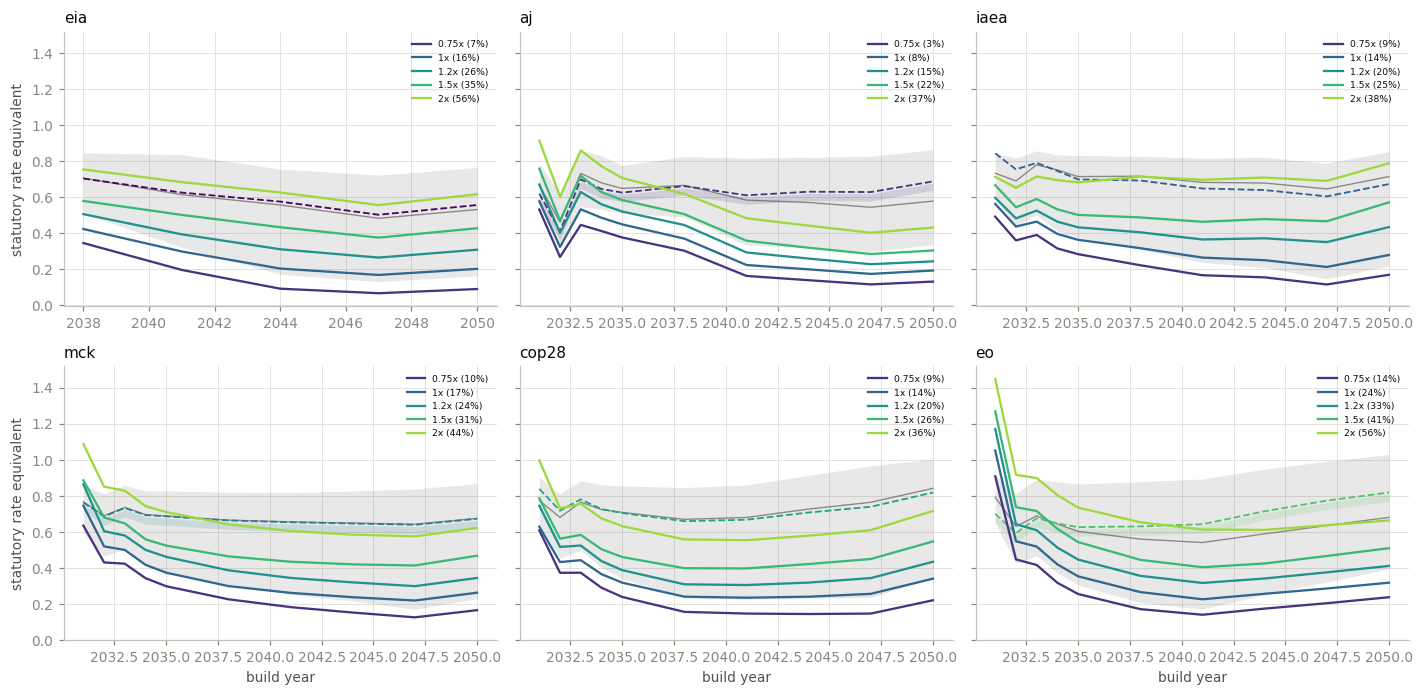

saved -> figures\w02_capture_vs_budget.png


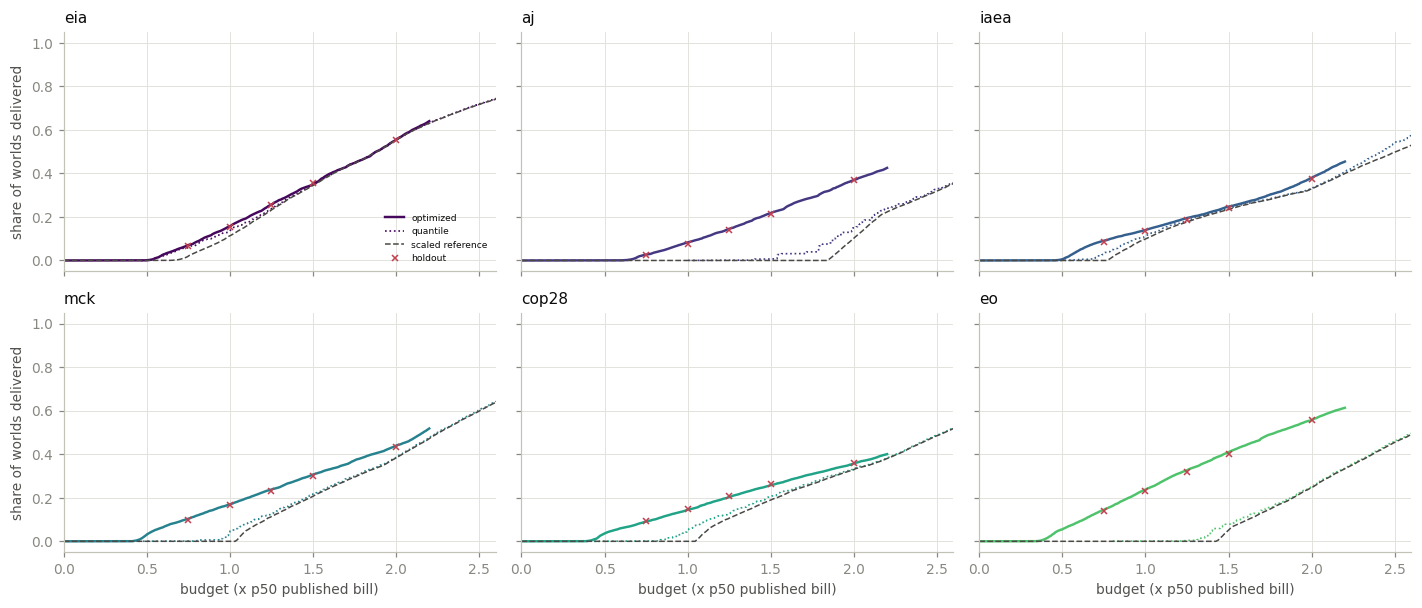

In [9]:
# w01: the contour figure (Fig 6 candidate) — requirement fan + optimal contours
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 6.4), sharey=True)
CB = plt.cm.viridis(np.linspace(0.15, 0.85, len(BUDGET_MULTS)))
for ax, ab in zip(axes.flat, SCHEDULES):
    ts = BUILD_TS[ab]
    occ_ref = OCCW[ab][ANCH[ab]["p50"]]
    q10, q50, q90 = np.percentile(IW[ab], [10, 50, 90], axis=0)
    ax.fill_between(ts, q10, q90, color=ps.BASE_C, alpha=0.12, lw=0)
    ax.plot(ts, q50, color=ps.BASE_C, lw=0.9, alpha=0.6)
    ax.plot(ts, IREF[ab], ls="--", color=ps.SCHED_C[ab], lw=1.2)
    if ab in {"aj", "mck", "eo"}:
        ax.fill_between(ts, np.maximum(IREF[ab] - 0.05, 0), np.maximum(IREF[ab] - 0.01, 0),
                        color=ps.SCHED_C[ab], alpha=0.15, lw=0)
    sub = u03[u03["schedule"] == ab].set_index("mult")
    for c, mult in zip(CB, BUDGET_MULTS):
        e = u02[(u02["schedule"] == ab) & (u02["mult"] == mult)]
        if not len(e) or (np.isfinite(sub.loc[mult, "clamp_contam"])
                          and sub.loc[mult, "clamp_contam"] > 0.05):
            continue
        cap = sub.loc[mult, "cap_greedy"]
        ax.plot(e["year"], e["rate_equiv"], color=c, lw=1.5,
                label=f"{mult:.2g}x ({cap:.0%})")
    ax.set_title(ab)
    ax.legend(fontsize=6, loc="upper right", frameon=False)
for ax in axes[1]:
    ax.set_xlabel("build year")
for ax in axes[:, 0]:
    ax.set_ylabel("statutory rate equivalent")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w01_contours.png")
plt.show()

# w02: capture vs budget — greedy vs quantile vs scaled (+ holdout markers)
fig, axes = plt.subplots(2, 3, figsize=(ps.W3, 5.6), sharex=True, sharey=True)
for ax, ab in zip(axes.flat, SCHEDULES):
    g_costs, g_counts, _ = CONTOUR[ab]["g"]
    q_costs = CONTOUR[ab]["q"]
    m_g = g_costs / P50BILL[ab]
    ax.plot(m_g, g_counts / 10000, color=ps.SCHED_C[ab], lw=1.6, label="optimized")
    ax.plot(q_costs / P50BILL[ab], np.arange(1, 10001) / 10000,
            color=ps.SCHED_C[ab], lw=1.1, ls=":", label="quantile")
    s_grid = np.linspace(0, 2.6 * P50BILL[ab] / SPREF[ab], 200)
    ax.plot(s_grid * SPREF[ab] / P50BILL[ab],
            [(FSTAR[ab] <= s).mean() for s in s_grid],
            color=ps.BASE_C, lw=1.0, ls="--", label="scaled reference")
    sub = u03[u03["schedule"] == ab]
    ax.plot(sub["mult"], sub["cap_holdout_B"], "x", color=ps.ACCENT["red"],
            ms=4, label="holdout")
    ax.set_xlim(0, 2.6)
    ax.set_title(ab)
axes[0, 0].legend(fontsize=6, frameon=False, loc="lower right")
for ax in axes[1]:
    ax.set_xlabel("budget (x p50 published bill)")
for ax in axes[:, 0]:
    ax.set_ylabel("share of worlds delivered")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w02_capture_vs_budget.png")
plt.show()


saved -> figures\w10_ci_curves.png


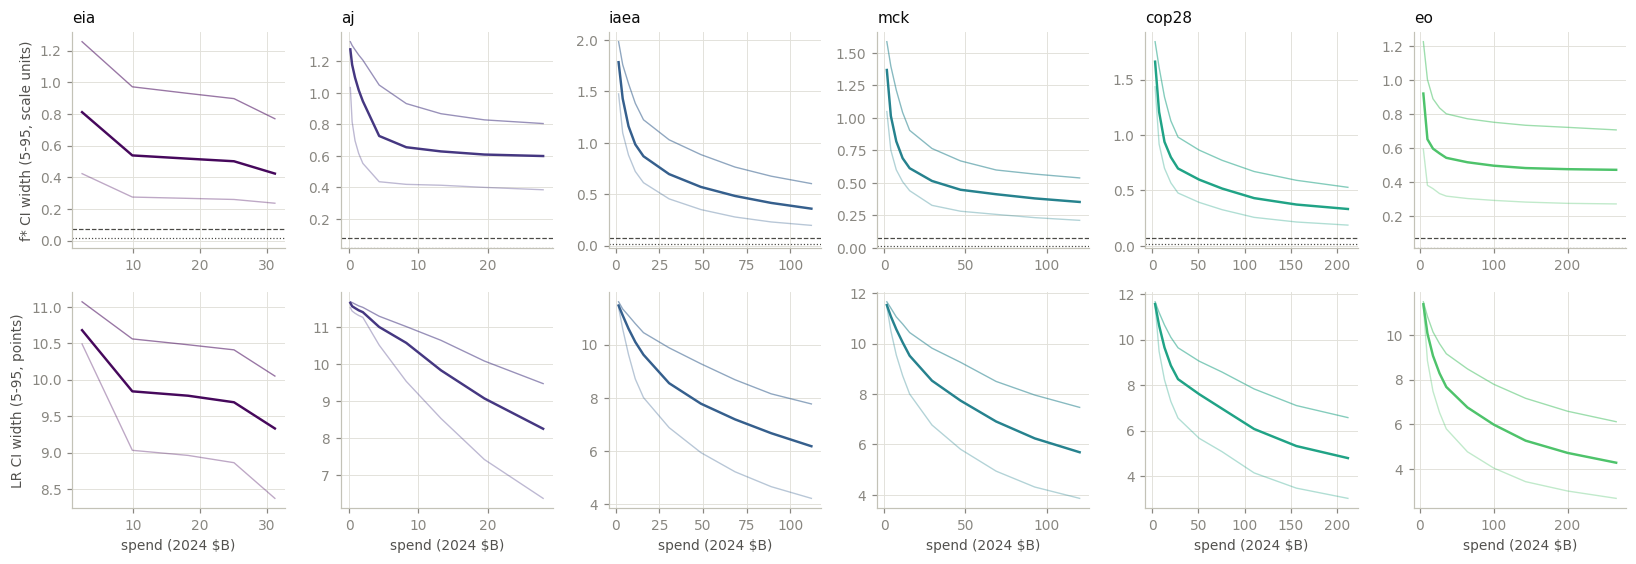

saved -> figures\w11_price_of_information.png


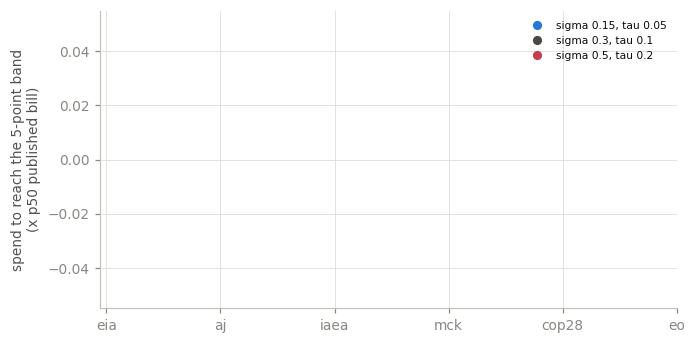

saved -> figures\w12_debug_ci.png


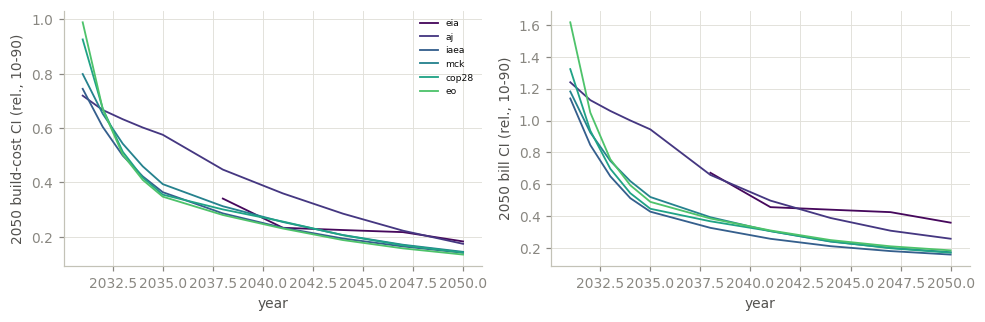

saved -> figures\w13_ess.png


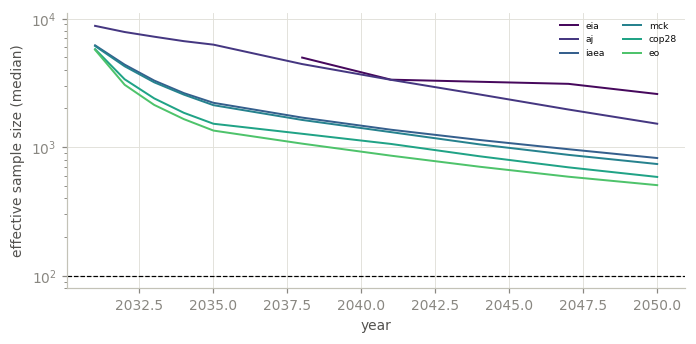

In [10]:
# w10: the co-headline CI curves (f* top row, learning rate bottom row)
LVC = {LEVELS[0]: 0.35, LEVELS[1]: 1.0, LEVELS[2]: 0.55}
fig, axes = plt.subplots(2, 6, figsize=(ps.W3 * 1.15, 5.2), sharex=False)
for ci, ab in enumerate(SCHEDULES):
    for lv in LEVELS:
        sub = u10[(u10["schedule"] == ab) & (u10["sigma"] == lv[0])
                  & (u10["tau"] == lv[1]) & (u10["k"] > 0)]
        lw = 1.6 if lv == LV_MID else 0.9
        al = LVC[lv]
        axes[0, ci].plot(sub["spend_med"], sub["fstar_w_med"],
                         color=ps.SCHED_C[ab], lw=lw, alpha=al)
        axes[1, ci].plot(sub["spend_med"], sub["lr_w_med"] * 100,
                         color=ps.SCHED_C[ab], lw=lw, alpha=al)
    axes[0, ci].axhline(TGT5[ab], color=ps.BASE_C, lw=0.8, ls="--")
    axes[0, ci].axhline(TGT1[ab], color=ps.BASE_C, lw=0.8, ls=":")
    axes[0, ci].set_title(ab)
    axes[1, ci].set_xlabel("spend (2024 $B)")
axes[0, 0].set_ylabel("f* CI width (5-95, scale units)")
axes[1, 0].set_ylabel("LR CI width (5-95, points)")
fig.tight_layout()
ps.savefig(fig, FIGURES / "w10_ci_curves.png")
plt.show()

# w11: the price of information (band-5 target, all noise levels)
fig, ax = plt.subplots(figsize=(ps.W1, 3.2))
xpos = np.arange(len(SCHEDULES))
for k_, lv in enumerate(LEVELS):
    sub = u11[(u11["sigma"] == lv[0]) & (u11["target"] == "band5")]
    sub = sub.set_index("schedule").reindex(SCHEDULES)
    y = sub["spend_over_p50bill"].to_numpy(float)
    ax.plot(xpos + (k_ - 1) * 0.15, y, "o", ms=5,
            color=[ps.ACCENT["blue"], ps.BASE_C, ps.ACCENT["red"]][k_],
            label=f"sigma {lv[0]}, tau {lv[1]}")
    for x_, yy, q in zip(xpos + (k_ - 1) * 0.15, y, sub["quotable"]):
        if np.isfinite(yy) and not bool(q):
            ax.plot(x_, yy, "x", ms=9, color="k")
ax.set_xticks(xpos, SCHEDULES)
ax.set_ylabel("spend to reach the 5-point band\n(x p50 published bill)")
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
ps.savefig(fig, FIGURES / "w11_price_of_information.png")
plt.show()

# w12: companion/debug curves — 2050 cost and 2050 bill relative widths
fig, axes = plt.subplots(1, 2, figsize=(ps.W2, 3.0), sharex=True)
for ab in SCHEDULES:
    sub = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0]) & (u10["k"] > 0)]
    axes[0].plot(sub["year"], sub["occ50_w_med"], color=ps.SCHED_C[ab], lw=1.2, label=ab)
    axes[1].plot(sub["year"], sub["bill_w_med"], color=ps.SCHED_C[ab], lw=1.2)
axes[0].set_ylabel("2050 build-cost CI (rel., 10-90)")
axes[1].set_ylabel("2050 bill CI (rel., 10-90)")
for ax in axes:
    ax.set_xlabel("year")
axes[0].legend(fontsize=6, frameon=False)
fig.tight_layout()
ps.savefig(fig, FIGURES / "w12_debug_ci.png")
plt.show()

# w13: the degeneracy table — median ESS by year (K5 floor marked)
fig, ax = plt.subplots(figsize=(ps.W1, 3.2))
for ab in SCHEDULES:
    sub = u12[(u12["schedule"] == ab) & (u12["sigma"] == LV_MID[0])]
    ax.plot(sub["year"], sub["ess_med"], color=ps.SCHED_C[ab], lw=1.3, label=ab)
ax.axhline(ESS_FLOOR, color="k", lw=0.8, ls="--")
ax.set_yscale("log")
ax.set_ylabel("effective sample size (median)")
ax.set_xlabel("year")
ax.legend(fontsize=6, frameon=False, ncol=2)
fig.tight_layout()
ps.savefig(fig, FIGURES / "w13_ess.png")
plt.show()


## S6 — the verdict: every gate and kill criterion, dispositioned

The kill criteria are evaluated mechanically from the exports; a KILL bars
the named object from the paper as designed (methods.md). Nothing downstream
is edited on this notebook's basis until the adversarial audit and Ethan's
ratification.

In [11]:
u03v = pd.read_csv(EXPORTS / "u03_capture_table.csv")
u11v = pd.read_csv(EXPORTS / "u11_price_of_information.csv")

# K1 overfitting: holdout drop <= 2 points at every reported budget
k1_worst = float(u03v["holdout_drop"].max())
VERDICT.append(("kill", "K1", "PASS" if k1_worst <= 0.02 else "KILL",
                f"worst greedy holdout drop {k1_worst:.3f} (limit 0.02); "
                f"quantile worst {float(u03v['holdout_drop_q'].max()):.3f}"))

# K2 simplicity: greedy must beat the quantile family by >= 1 point somewhere
k2_best = float(u03v["gain_vs_quantile"].max())
VERDICT.append(("kill", "K2", "PASS" if k2_best >= 0.01 else "DROP-OPTIMIZER",
                f"best greedy-vs-quantile gain {k2_best:.3f} "
                "(< 0.01 means the quantile family is the reported object)"))

# K3 certificate band: greedy-vs-scaled gain keeps its sign across +/-20%
k3_bad = u03v[(u03v["gain_vs_scaled"].abs() >= 0.005)
              & ((u03v["gain_sign_lo"] * np.sign(u03v["gain_vs_scaled"]) < 0)
                 | (u03v["gain_sign_hi"] * np.sign(u03v["gain_vs_scaled"]) < 0))]
VERDICT.append(("kill", "K3", "PASS" if not len(k3_bad) else "DEMOTE-SI",
                f"{len(k3_bad)} budget rows flip the greedy-vs-scaled gain sign "
                "inside the +/-20% band (rows with |gain| >= 0.005)"))

# K4 clamp ceiling: reported contours only where contamination <= 5%
k4_bad = u03v[u03v["clamp_contam"] > 0.05]
k4_ceiling = (u03v[u03v["clamp_contam"] <= 0.05].groupby("schedule")["mult"].max()
              .to_dict())
VERDICT.append(("kill", "K4", "ENFORCED",
                f"{len(k4_bad)} budget rows above the 5% clamp ceiling are not "
                f"reported; largest reportable budget per schedule: {k4_ceiling}"))

# K5 degeneracy: the band-5 crossing must sit at median ESS >= 100 (mid noise)
k5 = u11v[(u11v["sigma"] == LV_MID[0]) & (u11v["target"] == "band5")]
k5_bad = k5[(k5["year"] > 0) & (~k5["quotable"])]
k5_nohit = k5[k5["year"] < 0]
VERDICT.append(("kill", "K5", "PASS" if not len(k5_bad) else "KILL",
                f"{len(k5_bad)}/6 mid-noise band-5 crossings sit below the ESS "
                f"floor of {ESS_FLOOR:.0f}; {len(k5_nohit)} schedules never cross "
                "(handled under K7)"))

# K6 stability: replication IQR of the crossing spend <= 25% of the median
k6 = k5[np.isfinite(k5["rep_iqr_over_med"])]
k6_worst = float(k6["rep_iqr_over_med"].max()) if len(k6) else np.nan
VERDICT.append(("kill", "K6", "PASS" if (len(k6) == 0 or k6_worst <= 0.25) else "KILL",
                f"worst replication IQR/median of the crossing spend "
                f"{k6_worst if np.isfinite(k6_worst) else float('nan'):.3f} (limit 0.25)"))

# K7 honesty: never-crossing = asymptote finding; widening > 10% = bug/kill
k7_rows = []
for ab in SCHEDULES:
    sub = u10[(u10["schedule"] == ab) & (u10["sigma"] == LV_MID[0]) & (u10["k"] > 0)]
    tr = sub["fstar_w_med"].to_numpy(float)
    up = float((np.diff(tr) / np.maximum(tr[:-1], 1e-9)).max()) if len(tr) > 1 else 0.0
    k7_rows.append((ab, up))
k7_worst = max(u_ for _, u_ in k7_rows)
VERDICT.append(("kill", "K7", "PASS" if k7_worst <= 0.10 else "KILL",
                f"worst median-CI widening between consecutive observations "
                f"{k7_worst:.3f} (limit 0.10); never-crossing schedules reported "
                "as the information-price asymptote"))

u90 = pd.DataFrame(VERDICT, columns=["kind", "name", "result", "detail"])
u90.to_csv(EXPORTS / "u90_verdict.csv", index=False)
print(u90.to_string(index=False))


kind name   result                                                                                                                                                                       detail
gate   G0     PASS                                                                                                   b07 per-world bills reproduce published t08 at all 18 anchors (<=0.051 $B)
gate   G1     PASS                                                                                                       interpolation exact at all 18 anchors; p50 f* at the calibration point
gate   G3     PASS                                                                                                                          outlay calibration residual <= 7% at all 18 anchors
gate   G2     PASS                                                                                               reference = fed r01 headline (<=1e-6, aj/mck/eo); r03 bracket (head-5, head-1]
gate  G4a     PASS                      

In [12]:
# manifest
for p in sorted(EXPORTS.glob("u*.csv")) + sorted(FIGURES.glob("w*.png")):
    print(f"{p.relative_to(HERE)}  ({p.stat().st_size / 1024:.0f} kB)")


exports\u01_per_world_requirements.csv  (2407 kB)
exports\u02_contour_schedules.csv  (9 kB)
exports\u03_capture_table.csv  (4 kB)
exports\u10_ci_curves.csv  (22 kB)
exports\u11_price_of_information.csv  (2 kB)
exports\u12_ess.csv  (5 kB)
exports\u13_perfect_obs_bound.csv  (0 kB)
exports\u20_diagnostics.csv  (8 kB)
exports\u90_verdict.csv  (1 kB)
figures\w01_contours.png  (668 kB)
figures\w02_capture_vs_budget.png  (306 kB)
figures\w10_ci_curves.png  (553 kB)
figures\w11_price_of_information.png  (77 kB)
figures\w12_debug_ci.png  (221 kB)
figures\w13_ess.png  (128 kB)
